# 03: 断熱量子計算による最適化シミュレーション
### (Optimization via Adiabatic Quantum Computation)

---

## 1. Thesis: 科学的問いと仮説
量子コンピュータを用いて組み合わせ最適化問題を解く際、近似的な手法（QAOAなど）ではなく、物理的な「断熱プロセス」を忠実にたどることで、より高い確率で厳密解に到達できます。

**問い**: 特定のアルゴリズム（ゲート操作の組み合わせ）に依存せず、ハミルトニアン（エネルギー）の物理的な遷移をシミュレーションすることで、最適化問題を解くための本質的なプロセスをどう記述できるか？

**仮説**: 駆動ハミルトニアン $H_{driver}$（制約がない状態）から問題ハミルトニアン $H_{problem}$（制約された状態）へ、「エネルギーギャップ」を意識しながら十分ゆっくりと遷移させることで、システムの基底状態を維持し、最終的に最適解を得ることができる。

## 2. Theoretical Background (理論的背景)

### 2.1 断熱量子計算 (AQC) の基本概念
量子コンピュータを用いて組み合わせ最適化問題を解くアプローチとして、ゲートモデルによる「近似的」な手法（QAOAなど）とは対照的に、物理的な自然の遷移プロセスをそのまま利用するのが断熱量子計算 (Adiabatic Quantum Computation, AQC)、あるいは量子アニーリングの根底にある考え方です。

### 2.2 量子アニーリング (QA) との対比
断熱量子計算 (AQC) は、しばしば量子アニーリング (Quantum Annealing, QA) と共に語られます。両者の基本的なアイデア（自明な基底状態から問題の基底状態へ断熱的に遷移させること）は本質的には同じです。

しかし、厳密には以下のような違いがあります：

**量子アニーリング (QA)** ：  
主に量子アニーラで実装される手法です。システムは常に熱的な環境ノイズに晒されており、量子トンネル効果と熱揺らぎを利用して最適解（あるいは良い近似解）を探索するヒューリスティックなアプローチとして実用化されています。

**断熱量子計算 (AQC)** ：  
主に量子回路（ゲートモデル）上で理論的に語られる万能量子計算のモデルの一つです。このモデルは環境ノイズのない理想的な状態（純粋状態）でのユニタリ時間発展を仮定し、基底状態を厳密に追跡することを目的とした理論的・シミュレーション的側面が強いものです。
本ノートブックでは、後者の**AQC（ゲートモデル上のシミュレーション）**としての視点から、このプロセスを一歩ずつ追っていきます。

### 2.3 断熱定理 (Adiabatic Theorem)
AQCを支える物理法則が「断熱定理」です。 断熱定理とは、「対象とする量子系のハミルトニアンを **十分にゆっくりと（断熱的に）** 変化させた場合、システムは常にその瞬間瞬間の基底状態にとどまり続ける」という定理です。

これを利用し、AQCでは以下の手順を踏みます：

容易に基底状態を作れるような、単純な初期状態を用意する。
そのシステムを、時間をかけてゆっくりと「解きたい問題を表す状態」へと変化させる。
断熱定理により、最終的な状態は「解きたい問題の基底状態」、すなわち最適解に自然と到達している。

### 2.3 ハミルトニアンの構成と時間発展
システム全体を定義するエネルギーの枠組みをハミルトニアン ($H$) と呼びます。 シミュレーションで使用する全ハミルトニアン $H(t)$ は、時間 $t$ （$0 \le t \le T$）に依存し、以下の2つの項の線形結合で表されます。

$$ H(t) = \left( 1 - \frac{t}{T} \right) H_{driver} + \left( \frac{t}{T} \right) H_{problem} $$

1. 駆動ハミルトニアン $H_{driver}$ (driver Hamiltonian)  
すべての量子ビットに対する $X$ ゲートの和で構成されます。 $$ H_{driver} = - \sum_{i} X_i $$ この $H_{driver}$ の基底状態は、すべてのビットが $|+\rangle$ 状態（0と1の均等な重ね合わせ）にある状態です。これは探索空間のすべての解候補を等確率で重ね合わせた状態であり、ここからスタートします。  
マイナスがついているのは、初期状態は安定した状態（エネルギーが低い）であることと対応づけるためです。

2. 問題ハミルトニアン $H_{problem}$ (problem Hamiltonian)
解きたい最適化問題の制約条件やコスト関数を、$Z$ ゲートや $Z_i Z_j$ などの相互作用項にマッピングしたものです。 $$ H_{problem} = \sum_{i} h_i Z_i + \sum_{i,j} J_{i,j} Z_i Z_j $$ このハミルトニアンのエネルギーが最小（基底状態）になるビット列（0と1の組み合わせ）が、問題の正解となります。

### 2.4 トロッター分解による時間発展のシミュレーション
連続的なアナログ時間変化 $H(t)$ を、デジタルなゲート方式量子コンピュータでシミュレーションするために、全体の時間 $T$ を小さな時間ステップ $N$ 個（1ステップあたり $\Delta t = T/N$）に分割します。

これをトロッター分解 (Trotter-Suzuki decomposition) と呼びます。各ステップにおいて、$H_{driver}$ による微小な $RX$ 回転と、$H_{problem}$ による微小な $RZ$ および $RZZ$ 回転を交互に適用することで、なめらかな断熱変化を近似的に回路へ落とし込みます。 ステップ数 $N$ を増やす（ $\Delta t$ を小さくする）ほど、理論的な断熱プロセスに近づき、正解を得る確率が高まります。

## 3. Implementation (実装)
本セクションでは、実際に **Qiskit** を用いてAQC（断熱量子計算）のプロセスをシミュレーションします。
対象とする問題は、3つのノード（0, 1, 2）が直線上に並んだグラフ `0 -- 1 -- 2` の **最大カット問題（Max-Cut Problem）** です。
隣り合うノードを異なるグループに分けることでカット線分の数を最大化する問題であり、直感的には `010` と `101` （両端が同じグループで、真ん中が違うグループ）が最適解となります。
以下のコードでは、これを関数 `run_adiabatic_optimization` として実装し、
1. **アニーリングスケジュールの可視化**
2. **トロッター分解による量子回路の構築**
3. **シミュレーション実行と測定**
4. **結果の可視化（測定確率とカット数の棒グラフ比較）**
の順に処理を進めます。

## 4. Visualization & Analysis (可視化と解析)

構築した断熱プロセス回路をシミュレータで実行し、最終状態をサンプリングする動作を可視化します。


--- AQC最適化シミュレーション (Max-Cut問題) ---
グラフ構造: 0 -- 1 -- 2 (ノード数: 3, エッジ数: 2)
アニーリング時間(T): 10.0, ステップ数(N): 40


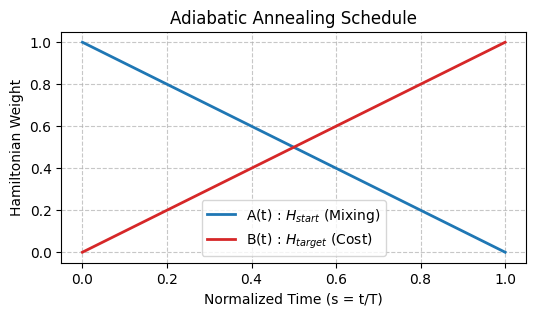

回路が構築されました。回路の深さ(Depth): 282

--- シミュレーション実行 ---
構築した断熱プロセス回路をシミュレータで実行し、最終状態をサンプリングします。

--- 測定結果 ---
状態 |101⟩:  519回 ( 50.7%) -> カット数: 2
状態 |010⟩:  504回 ( 49.2%) -> カット数: 2
状態 |110⟩:    1回 (  0.1%) -> カット数: 1


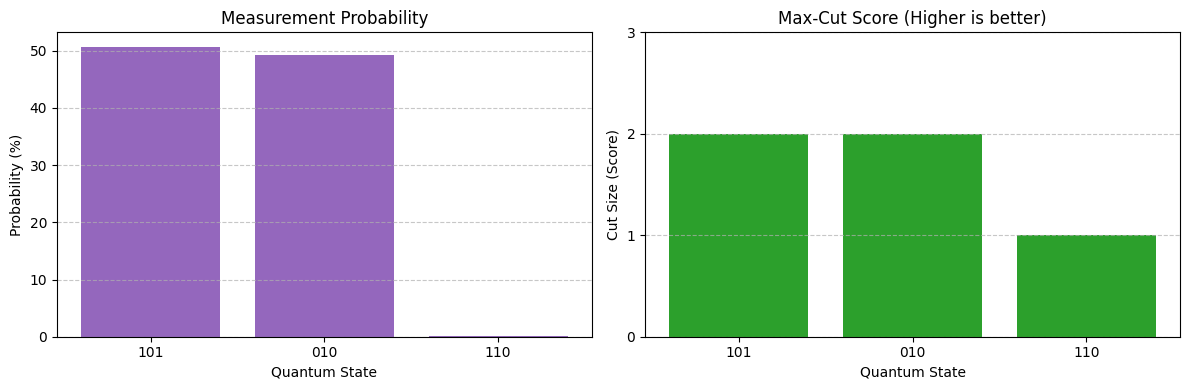

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator

def run_adiabatic_optimization(T: float = 10.0, N: int = 40) -> None:
    """量子断熱計算(AQC)による組み合わせ最適化シミュレーションを実行します。

    Theory:
        - 初期ハミルトニアン (H_start): 全量子ビットにXをかける操作。
          初期状態は、基底状態である |+> に設定されます。
        - 目的ハミルトニアン (H_target): エッジ (i, j) 間の Z_i * Z_j 結合。
        - 時間発展 (Trotter分解): Nステップに分けて、A(t)*H_start と B(t)*H_target を
          交互に適用し、システムをゆっくりと変化させます。
          - A_schedule: 1.0 から 0.0 へ減少 (X回転が弱まる)
          - B_schedule: 0.0 から 1.0 へ増加 (ZZ結合が強まる)

    Args:
        T (float, optional): 全体のアニーリング時間。
            大きいほど「ゆっくり」と変化し、断熱条件を満たしやすくなります。Defaults to 10.0.
        N (int, optional): トロッター分解のステップ数。
            大きいほど連続的な時間変化を「なめらか」に近似できます。Defaults to 40.
    """
    print("\n--- AQC最適化シミュレーション (Max-Cut問題) ---")
    
    # 1. 問題の定義
    num_qubits = 3
    edges = [(0, 1), (1, 2)]
    print(f"グラフ構造: 0 -- 1 -- 2 (ノード数: {num_qubits}, エッジ数: {len(edges)})")
    print(f"アニーリング時間(T): {T:.1f}, ステップ数(N): {N}")

    dt = T / N

    # 2. アニーリングスケジュールの計算
    s_values = np.linspace(0, 1, N + 1)
    A_schedule = 1 - s_values  # H_start の係数
    B_schedule = s_values      # H_target の係数

    plt.figure(figsize=(6, 3))
    plt.plot(s_values, A_schedule, label="A(t) : $H_{start}$ (Mixing)", color='#1f77b4', linewidth=2)
    plt.plot(s_values, B_schedule, label="B(t) : $H_{target}$ (Cost)", color='#d62728', linewidth=2)
    plt.xlabel("Normalized Time (s = t/T)")
    plt.ylabel("Hamiltonian Weight")
    plt.title("Adiabatic Annealing Schedule")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

    # 3. 量子回路の構築
    qc = QuantumCircuit(num_qubits)
    qc.h(range(num_qubits))
    qc.barrier()

    for step in range(N):
        A = A_schedule[step]
        B = B_schedule[step]
        
        for i in range(num_qubits):
            qc.rx(-2 * A * dt, i) 
        
        for i, j in edges:
            qc.cx(i, j)
            qc.rz(2 * B * dt, j)
            qc.cx(i, j)
            
        qc.barrier()

    qc.measure_all()
    print(f"回路が構築されました。回路の深さ(Depth): {qc.depth()}")

    # 4. シミュレーション実行
    print("\n--- シミュレーション実行 ---")
    print("構築した断熱プロセス回路をシミュレータで実行し、最終状態をサンプリングします。")
    sim = AerSimulator()
    qc_compiled = transpile(qc, sim)
    
    shots = 1024
    result = sim.run(qc_compiled, shots=shots).result()
    counts = result.get_counts()  # <- ここでエラーなく、必ずシミュレータから確率分布(counts)を取り出します
    
    # 5. 結果の表示と可視化
    print("\n--- 測定結果 ---")
    sorted_counts = dict(sorted(counts.items(), key=lambda x: x[1], reverse=True))
    
    def calculate_cut_size(bitstring, edges):
        cut_size = 0
        bits = bitstring[::-1]
        for i, j in edges:
            if bits[i] != bits[j]:
                cut_size += 1
        return cut_size

    states, probs, cut_sizes = [], [], []
    for i, (state, count) in enumerate(sorted_counts.items()):
        if i >= 5:
            break
        prob = count / shots * 100
        score = calculate_cut_size(state, edges)
        states.append(state)
        probs.append(prob)
        cut_sizes.append(score)
        print(f"状態 |{state}⟩: {count:4d}回 ({prob:5.1f}%) -> カット数: {score}")

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    ax1.bar(states, probs, color='#9467bd')
    ax1.set_xlabel("Quantum State")
    ax1.set_ylabel("Probability (%)")
    ax1.set_title("Measurement Probability")
    ax1.grid(axis='y', linestyle='--', alpha=0.7)
    
    ax2.bar(states, cut_sizes, color='#2ca02c')
    ax2.set_xlabel("Quantum State")
    ax2.set_ylabel("Cut Size (Score)")
    ax2.set_title("Max-Cut Score (Higher is better)")
    ax2.set_yticks(range(0, 4))
    ax2.grid(axis='y', linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.show()

# ここで関数を呼び出して実行します！
run_adiabatic_optimization(T=10.0, N=40)


## 5. Conclusion & Future Work (結論と展望)

### 結論
本ノートブックでは、ハミルトニアンの連続的な時間発展をシミュレーションすることで最適解を探索する「断熱量子計算 (AQC)」の基本原理を実装し、その挙動を確認しました。以下の重要な洞察が得られました：

**断熱定理の再現** :  
初期状態（すべての可能性の重ね合わせ）から目的状態（最適解）へ、系をゆっくりと変化させることで、高い確率で正解（基底状態）へ到達できることが物理シミュレーションとして実証されました。

**トロッター分解による近似** :  
連続的なアナログ変化を、離散的なデジタルゲート操作（$RX, RZ, RZZ$ ゲートの交互適用）で近似できることが確認できました。
ステップ数と精度のトレードオフ: 時間発展の分割ステップ数 $N$ を増やすほど近似精度が上がり正解率が高まる一方で、実際の量子回路としての「深さ（Depth）」が増大し、現実のハードウェアではノイズの影響を受けやすくなるというハードウェア実装上のジレンマが浮き彫りになりました。

### 展望
QAOA（量子近似最適化アルゴリズム）への展開: AQCは理論的に強力ですが、回路が深すぎるため現在のNISQデバイスには不向きです。AQCの「連続変化を離散化して交互にゲートをかける」というステップをベースにしつつ、その回転角（パラメータ）を古典コンピュータに機械学習させて大幅に回路を浅くするハイブリッド進化版が QAOA です。次はQAOAの実装へ進みます。

**エネルギーギャップの研究** :  
特定の問題（例：巡回セールスマン問題やSAT問題）において、探索の途中で基底状態と第一励起状態のエネルギー差（ギャップ）が極端に狭くなる現象があります。ここで変化を急ぐと状態が遷移してしまうため、ギャップに合わせて変化のスピードを動的に調整する「スケジューリング関数」の高度化が今後の研究課題となります。

**実機アニーラへの適用** :  
本ノートブックはゲート型量子コンピュータ上でのAQCシミュレーションでしたが、この背後にある数理モデルは D-Wave に代表される量子アニーリングマシンへ直接マッピングする（QUBO形式での定式化）ための強固な理論的土台となります。